In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

azimuth,elevation,ratio,v1,v2 = np.loadtxt('prvoMjerenje.csv', delimiter=",", dtype = 'float', unpack=True)
len(elevation)

4200

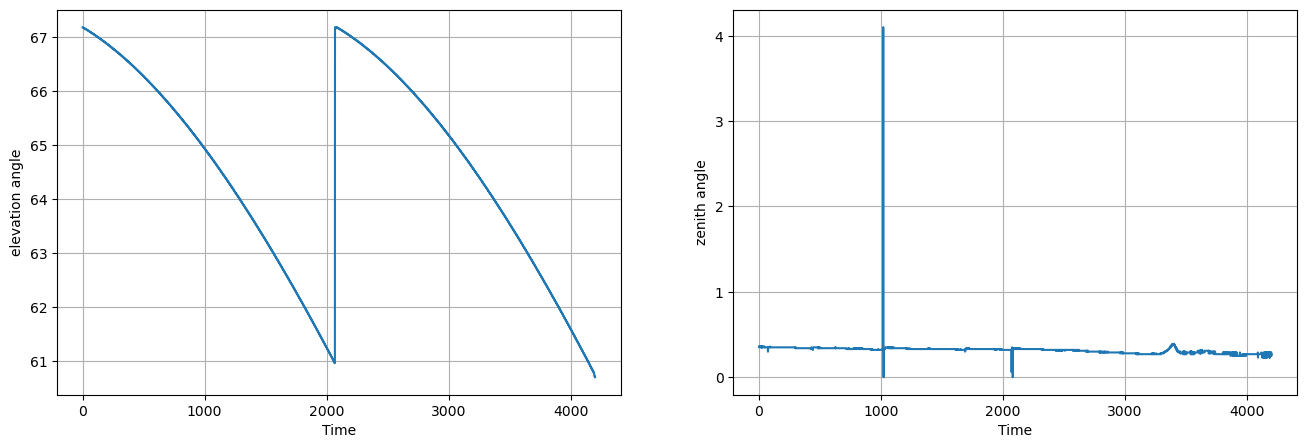

In [2]:
sza = 90-elevation
time = np.arange(0,len(sza),1)

window=len(ratio)
avgRatio = signal.savgol_filter(ratio, window,2)

fig, ax = plt.subplots(1,2,figsize=(16,5))
ax[0].plot(time, elevation, linestyle='-')
ax[0].set(xlabel='Time', ylabel='elevation angle',title='')
ax[0].grid()
ax[1].plot(time, ratio, linestyle='-')
ax[1].set(xlabel='Time', ylabel='zenith angle',title='')
ax[1].grid()
plt.show()
plt.close(fig)

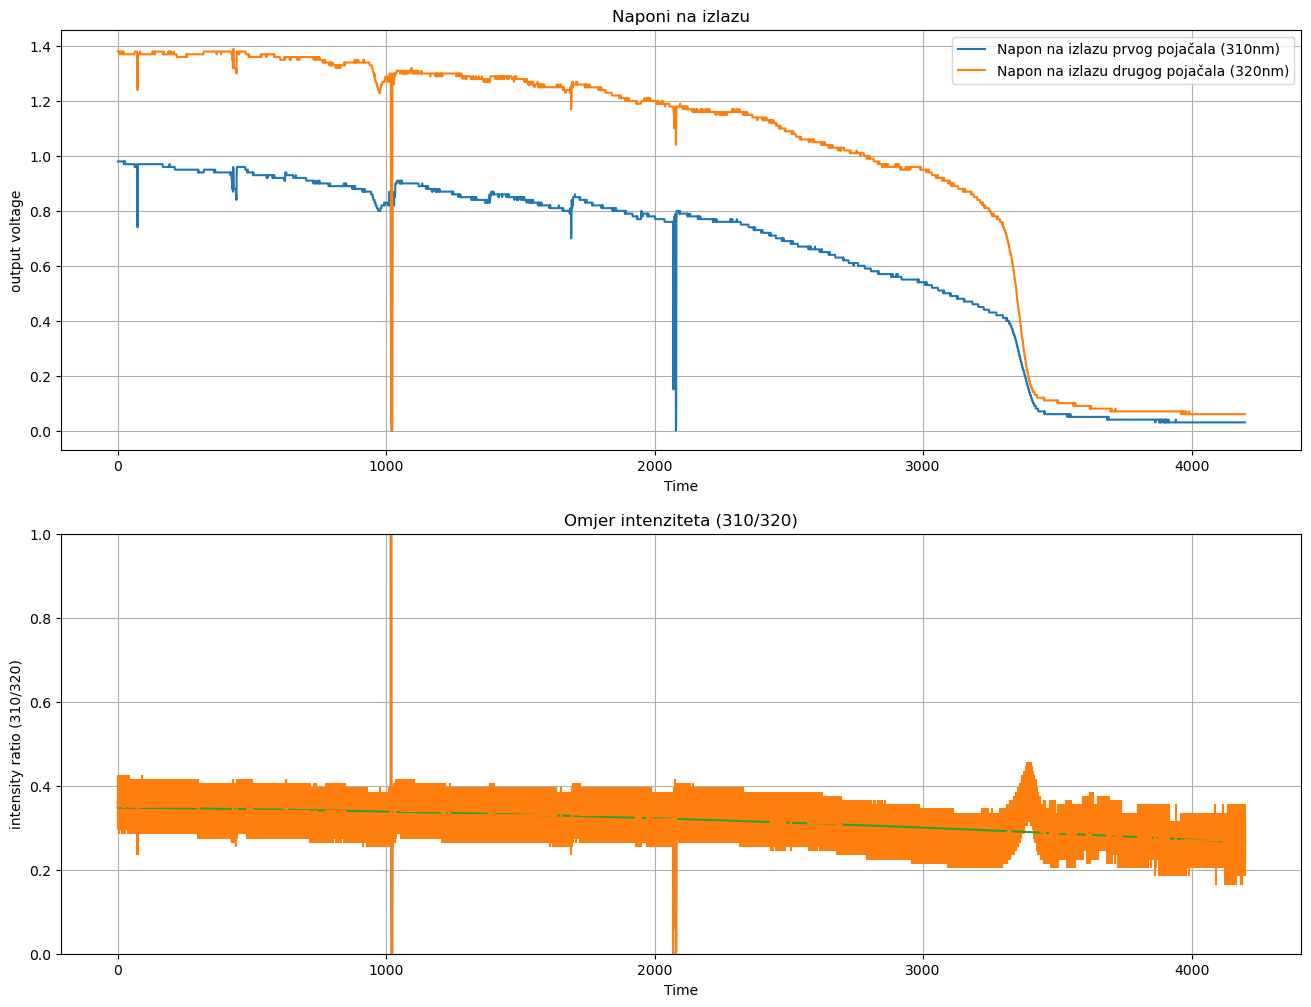

In [3]:
fig, ax = plt.subplots(2,1,figsize=(16,12))
ax[0].plot(time, v1, linestyle='-',label='Napon na izlazu prvog pojačala (310nm)')
ax[0].plot(time, v2, linestyle='-',label='Napon na izlazu drugog pojačala (320nm)')
ax[0].set(xlabel='Time', ylabel='output voltage',title='Naponi na izlazu')
ax[0].grid()
ax[0].legend(loc='best')
ax[1].plot(time, ratio, linestyle='-')
ax[1].errorbar(time, ratio,np.std(ratio), linestyle='-')
ax[1].plot(time, avgRatio, linestyle='-')
ax[1].set(xlabel='Time', ylabel='intensity ratio (310/320)',title='Omjer intenziteta (310/320)',ylim=(0,1))
ax[1].grid()
plt.show()
plt.close(fig)

In [4]:
## 66.67 minuta mjerenja
log = -np.log(ratio[0]-ratio[2000])
kosinus = np.cos(np.deg2rad(elevation[0]-elevation[2000]))
log,kosinus

(3.2188758248682015, 0.9946308119914323)